# Linear Regression with Single Variable

In this notebook, we'll practice implementing simple linear regression using the Housing dataset. We'll analyze the relationship between house area and price.

## Import Required Libraries

First, let's import all the necessary libraries we'll need for our analysis.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import os

## Load Dataset

Let's load the Housing dataset and take a look at its structure.

In [2]:
# Read the dataset
df = pd.read_csv('Housing.csv')

# Display the first few rows
print("First few rows of the dataset:")
print(df.head())

# Display basic information about the dataset
print("\nDataset Info:")
print(df.info())

First few rows of the dataset:
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545

## Data Visualization

Let's create a scatter plot to visualize the relationship between house area and price.

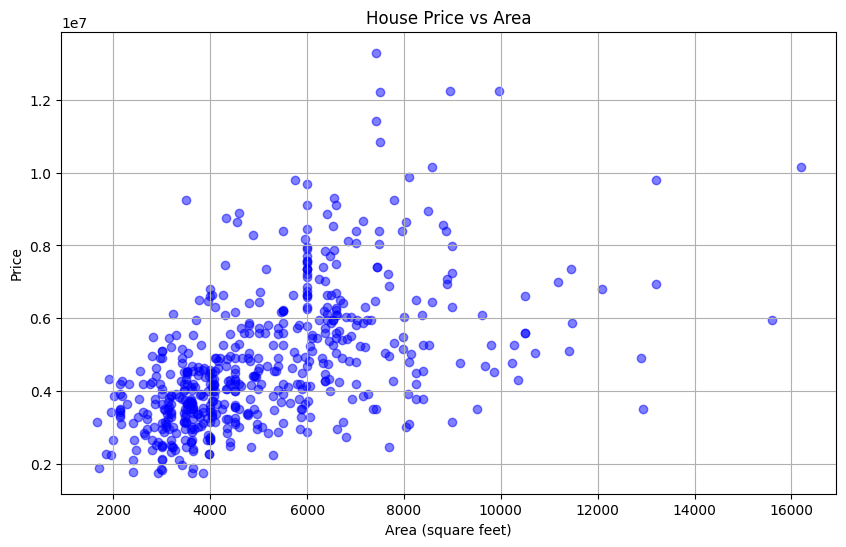

In [3]:
# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(df['area'], df['price'], color='blue', alpha=0.5)
plt.xlabel('Area (square feet)')
plt.ylabel('Price')
plt.title('House Price vs Area')
plt.grid(True)
plt.show()

## Create and Train Linear Regression Model

Now we'll create a linear regression model to predict house prices based on area.

In [4]:
# Prepare the data
X = df['area'].values.reshape(-1, 1)  # Independent variable
y = df['price'].values  # Dependent variable

# Create and train the model
model = LinearRegression()
model.fit(X, y)

# Print the model coefficients
print(f'Intercept (β₀): {model.intercept_:.2f}')
print(f'Coefficient (β₁): {model.coef_[0]:.2f}')
print(f'\nLinear equation: Price = {model.intercept_:.2f} + {model.coef_[0]:.2f} × Area')

Intercept (β₀): 2387308.48
Coefficient (β₁): 461.97

Linear equation: Price = 2387308.48 + 461.97 × Area


## Visualize the Regression Line

Let's plot the regression line along with the scatter plot to see how well our model fits the data.

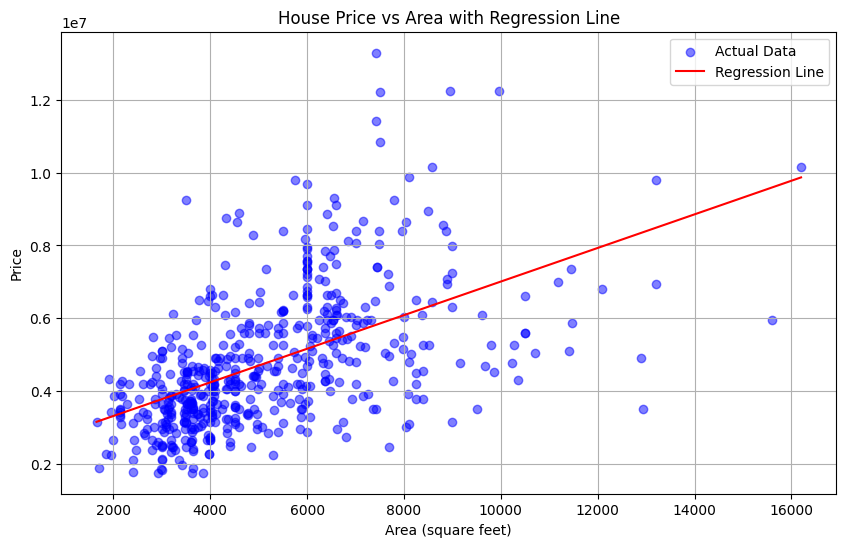

In [5]:
# Create predictions for plotting
X_plot = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_plot = model.predict(X_plot)

# Plot the data and regression line
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', alpha=0.5, label='Actual Data')
plt.plot(X_plot, y_plot, color='red', label='Regression Line')
plt.xlabel('Area (square feet)')
plt.ylabel('Price')
plt.title('House Price vs Area with Regression Line')
plt.legend()
plt.grid(True)
plt.show()

## Model Evaluation and Predictions

Let's evaluate our model's performance and save the predictions to a file.

In [6]:
# Make predictions
y_pred = model.predict(X)

# Calculate R-squared score
r2_score = model.score(X, y)
print(f'R-squared Score: {r2_score:.4f}')

# Create a DataFrame with actual and predicted values
results_df = pd.DataFrame({
    'Area': df['area'],
    'Actual_Price': df['price'],
    'Predicted_Price': y_pred
})

# Save predictions to file
output_file = 'linear_regression_output.csv'
results_df.to_csv(output_file, index=False)
print(f'\nPredictions saved to {output_file}')

# Display first few predictions
print('\nFirst few predictions:')
print(results_df.head())

R-squared Score: 0.2873

Predictions saved to linear_regression_output.csv

First few predictions:
   Area  Actual_Price  Predicted_Price
0  7420      13300000     5.815162e+06
1  8960      12250000     6.526604e+06
2  9960      12250000     6.988578e+06
3  7500      12215000     5.852120e+06
4  7420      11410000     5.815162e+06


## Compare Actual vs Predicted Prices

Let's create a visualization to compare how well our predictions match the actual house prices.

In [ ]:
# Create a comparison plot
plt.figure(figsize=(12, 6))

# Plot actual vs predicted prices
plt.scatter(df['price'], y_pred, color='blue', alpha=0.5, label='Predictions')
plt.plot([df['price'].min(), df['price'].max()], [df['price'].min(), df['price'].max()], 
         'r--', label='Perfect Prediction')

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted House Prices')
plt.legend()
plt.grid(True)

# Add text box with R-squared value
plt.text(0.05, 0.95, f'R² = {r2_score:.4f}', 
         transform=plt.gca().transAxes, 
         bbox=dict(facecolor='white', alpha=0.8))

plt.show()

# Calculate and display some error metrics
errors = df['price'] - y_pred
mae = np.mean(np.abs(errors))
mse = np.mean(errors ** 2)
rmse = np.sqrt(mse)

print("Error Metrics:")
print(f"Mean Absolute Error: {mae:,.2f}")
print(f"Mean Squared Error: {mse:,.2f}")
print(f"Root Mean Squared Error: {rmse:,.2f}")